# 3.7 — Ordinal Regression on Binned Health Gain

Instead of regressing a continuous `health_gain`, we **bin** it into four clinically meaningful categories
and train a **CatBoost multi-class ordinal classifier**.

**Bins:**

| Class | Label | Condition |
|---|---|---|
| 0 | Worsened | `health_gain < 0` |
| 1 | Minimal benefit | `0 <= health_gain < 7` |
| 2 | Moderate benefit | `7 <= health_gain < 15` |
| 3 | Strong benefit | `health_gain >= 15` |

**Rationale:** Ordinal classification may be easier to learn than exact regression, and bin-level
predictions map directly to clinical decision categories. We convert predictions back to a derived RMSE
(using bin means from the training set) for comparison against the regression baseline.

| | |
|---|---|
| **Data** | `./data/interim/2.0-preprocessing.parquet` (same pipeline as 3.5) |
| **Null handling** | `drop_nulls()` — listwise deletion |
| **Split** | Year-based (last year = test) |
| **Model** | CatBoost with `loss_function=MultiClass` |
| **HPO** | Optuna 40 trials, minimising ordinal MAE in 5-fold CV |
| **Regression baseline** | CatBoost RMSE = **8.0186**, R² = 0.2952 (notebook 3.2) |

## 0. Imports & Setup

In [1]:
import subprocess, sys
_packages = [
    'polars', 'scikit-learn', 'catboost', 'joblib',
    'matplotlib', 'seaborn', 'numpy', 'pandas', 'optuna', 'scipy',
]
for pkg in _packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])
print('All dependencies installed.')

All dependencies installed.


In [2]:
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

import polars as pl
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from catboost import CatBoostClassifier

print('All imports OK.')

All imports OK.


In [3]:
# ── Constants & results cache ────────────────────────────────────────────────
BASELINE_RMSE = 8.0186   # 3.2 CatBoost, Pipeline1
BASELINE_R2   = 0.2952
N_TRIALS      = 40
RANDOM_STATE  = 42

# Clinical bins for health_gain
BIN_EDGES  = [-np.inf, 0, 7, 15, np.inf]
BIN_LABELS = ['Worsened (<0)', 'Minimal (0-7)', 'Moderate (7-15)', 'Strong (>=15)']
N_CLASSES  = 4

RESULTS_CACHE = Path('./models/3.4-improvement_cache.joblib')
RESULTS_CACHE.parent.mkdir(parents=True, exist_ok=True)

if RESULTS_CACHE.exists():
    improvement_results = joblib.load(RESULTS_CACHE)
    print(f'Loaded cache ({len(improvement_results)} entries): {list(improvement_results.keys())}')
else:
    improvement_results = {}

def _record(label: str, test_rmse: float, test_r2: float, notes: str = '', extra: dict = None):
    improvement_results[label] = {
        'test_rmse': test_rmse, 'test_r2': test_r2,
        'notes': notes, 'delta_rmse': BASELINE_RMSE - test_rmse,
        **(extra or {}),
    }
    joblib.dump(improvement_results, RESULTS_CACHE)
    print(f'  [{label}]  RMSE={test_rmse:.4f}  R²={test_r2:.4f}  Δ={BASELINE_RMSE-test_rmse:+.4f}')

print(f'Baseline: RMSE={BASELINE_RMSE}  R²={BASELINE_R2}')

Baseline: RMSE=8.0186  R²=0.2952


## 1. Data Preparation

Same pipeline as notebook 3.5: `2.0-preprocessing.parquet`, drop post-op columns and nulls, year-based split. `health_gain` is computed from post-op score minus the sum of the 12 individual pre-op OKS questions.

In [4]:
# ── Load from 2.0-preprocessing.parquet (same as 3.5) ────────────────────────
df_raw = pl.read_parquet('./data/interim/2.0-preprocessing.parquet')
print(f'Raw shape: {df_raw.shape}')

TARGET_POSTOP = 'Knee Replacement Post-Op Q Score'
assert TARGET_POSTOP in df_raw.columns

post_op_cols   = [c for c in df_raw.columns if 'Post-Op' in c and c != TARGET_POSTOP]
predicted_cols = [c for c in df_raw.columns if 'Predicted' in c]
admin_cols = [
    'Knee Replacement Pre-Op Q Score',
    'Pre-Op Q EQ5D Index Profile', 'Pre-Op Q EQ5D Index',
    'Provider Code', 'Procedure', 'CSVYear',
    'Pre-Op Q Assisted By', 'Pre-Op Q EQ VAS',
]
drop_exist = [c for c in set(admin_cols + post_op_cols + predicted_cols) if c in df_raw.columns]
df_ord = df_raw.drop(drop_exist)

n_before = df_ord.shape[0]
df_ord   = df_ord.drop_nulls()
print(f'Rows: {n_before:,} → {df_ord.shape[0]:,}  (removed {n_before - df_ord.shape[0]:,} with nulls)')

Raw shape: (139236, 61)
Rows: 139,236 → 112,652  (removed 26,584 with nulls)


In [5]:
# ── Year-based split + compute health_gain ───────────────────────────────────
YEAR_COL  = 'Year'
test_year = int(df_ord[YEAR_COL].unique().sort()[-1])
df_ord_train = df_ord.filter(pl.col(YEAR_COL) < test_year)
df_ord_test  = df_ord.filter(pl.col(YEAR_COL) == test_year)
print(f'Train: {df_ord_train.shape[0]:,}  Test: {df_ord_test.shape[0]:,}  (test year: {test_year})')

OKS_COLS_ORD = [c for c in df_ord_train.columns if 'Knee Replacement Pre-Op Q' in c]
feat_ord     = [c for c in df_ord_train.columns if c not in [TARGET_POSTOP, YEAR_COL]]

pre_op_tr = df_ord_train.select(OKS_COLS_ORD).to_numpy().sum(axis=1)
pre_op_te = df_ord_test.select(OKS_COLS_ORD).to_numpy().sum(axis=1)

y_hg_tr = (df_ord_train[TARGET_POSTOP].to_numpy() - pre_op_tr).astype(float)
y_hg_te = (df_ord_test[TARGET_POSTOP].to_numpy()  - pre_op_te).astype(float)

X_ord_tr = df_ord_train.select(feat_ord).to_pandas()
X_ord_te = df_ord_test.select(feat_ord).to_pandas()

print(f'health_gain  mean={y_hg_tr.mean():.2f}  std={y_hg_tr.std():.2f}  range=[{y_hg_tr.min():.0f},{y_hg_tr.max():.0f}]')

Train: 75,774  Test: 36,878  (test year: 3)
health_gain  mean=16.86  std=9.76  range=[-37,47]


## 2. Ordinal Binning

Bin `health_gain` into 4 clinical categories. Bin means are computed **on training data only** and used later to convert ordinal predictions back to a health_gain estimate for RMSE comparison.

In [6]:
# ── Encode ordinal labels & compute bin statistics from train ─────────────────
def encode_ordinal(hg: np.ndarray) -> np.ndarray:
    """Map health_gain to ordinal class 0-3."""
    return np.digitize(hg, bins=[0, 7, 15]).astype(int)

y_ord_tr = encode_ordinal(y_hg_tr)
y_ord_te = encode_ordinal(y_hg_te)

# Bin means on TRAIN only (used later to derive RMSE from ordinal predictions)
bin_means = {}
for b in range(N_CLASSES):
    mask = y_ord_tr == b
    bin_means[b] = float(y_hg_tr[mask].mean()) if mask.sum() > 0 else 0.0

print('Bin distribution (train):')
total_tr = len(y_ord_tr)
for b, label in enumerate(BIN_LABELS):
    n = (y_ord_tr == b).sum()
    print(f'  Class {b}  {label:<22}  {n:6,}  ({100*n/total_tr:.1f}%)  mean_hg={bin_means[b]:.1f}')

print('\nBin distribution (test):')
total_te = len(y_ord_te)
for b, label in enumerate(BIN_LABELS):
    n = (y_ord_te == b).sum()
    print(f'  Class {b}  {label:<22}  {n:6,}  ({100*n/total_te:.1f}%)')

Bin distribution (train):
  Class 0  Worsened (<0)            3,487  (4.6%)  mean_hg=-5.0
  Class 1  Minimal (0-7)            7,649  (10.1%)  mean_hg=3.5
  Class 2  Moderate (7-15)         18,310  (24.2%)  mean_hg=10.9
  Class 3  Strong (>=15)           46,328  (61.1%)  mean_hg=23.1

Bin distribution (test):
  Class 0  Worsened (<0)            1,568  (4.3%)
  Class 1  Minimal (0-7)            3,569  (9.7%)
  Class 2  Moderate (7-15)          8,599  (23.3%)
  Class 3  Strong (>=15)           23,142  (62.8%)


In [7]:
# ── Preprocess features ───────────────────────────────────────────────────────
num_ord = X_ord_tr.select_dtypes(include=['number']).columns.tolist()
cat_ord = X_ord_tr.select_dtypes(exclude=['number']).columns.tolist()
print(f'Numeric: {len(num_ord)}  Categorical: {len(cat_ord)}')

num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
])
transformers = [('num', num_pipe, num_ord)]
if cat_ord:
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    transformers.append(('cat', cat_pipe, cat_ord))

pre_ord = ColumnTransformer(transformers, remainder='drop')
X_ord_tr_prep = pre_ord.fit_transform(X_ord_tr)
X_ord_te_prep = pre_ord.transform(X_ord_te)
print(f'Feature matrix: train={X_ord_tr_prep.shape}  test={X_ord_te_prep.shape}')

Numeric: 41  Categorical: 0


Feature matrix: train=(75774, 41)  test=(36878, 41)


## 3. Ordinal Regression with CatBoost MultiClass

CatBoost's `MultiClass` objective treats the 4 bins as an ordered classification task. Optuna minimises **ordinal MAE** (mean absolute error in the 0-3 bin space) via 5-fold cross-validation over 40 trials.

In [8]:
# ── Optuna: CatBoost MultiClass with ordinal MAE scoring ─────────────────────
import time

def ordinal_mae_scorer(estimator, X, y):
    """Custom scorer: negative ordinal MAE (higher = better for cross_val_score)."""
    y_pred = estimator.predict(X).flatten().astype(int)  # flatten: MultiClass predict can be 2D
    return -float(np.abs(y_pred - y).mean())

_trial_times_ord = []

def objective_ord(trial):
    t0 = time.time()
    params = {
        'iterations'      : trial.suggest_int('iterations', 200, 800, step=100),
        'depth'           : trial.suggest_int('depth', 4, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg'     : trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 80),
        'loss_function'   : 'MultiClass',
        'classes_count'   : N_CLASSES,
        'random_seed'     : RANDOM_STATE,
        'verbose'         : 0,
        'thread_count'    : 1,  # use 1 thread: avoids conflict with n_jobs=-1 in cross_val_score
    }
    mdl    = CatBoostClassifier(**params)
    scores = cross_val_score(
        mdl, X_ord_tr_prep, y_ord_tr,
        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring=ordinal_mae_scorer,
        n_jobs=-1,  # parallelise folds; CatBoost uses thread_count=1 per fold
    )
    val_mae = -scores.mean()
    elapsed = time.time() - t0
    _trial_times_ord.append(elapsed)
    n   = len(_trial_times_ord)
    eta = (sum(_trial_times_ord) / n) * (N_TRIALS - n)
    print(f'  Trial {n:>3}/{N_TRIALS}  ordinal_MAE={val_mae:.4f}  ETA={eta:.0f}s', end='\r')
    return val_mae

study_ord = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)
study_ord.optimize(objective_ord, n_trials=N_TRIALS, show_progress_bar=False)
print(f'\nBest CV ordinal MAE : {study_ord.best_value:.4f}')
print(f'Best params         : {study_ord.best_params}')


  Trial  40/40  ordinal_MAE=0.4866  ETA=0ssss
Best CV ordinal MAE : 0.4857
Best params         : {'iterations': 700, 'depth': 5, 'learning_rate': 0.03838331032797079, 'l2_leaf_reg': 2.302230307837834, 'min_data_in_leaf': 11}


In [9]:
# ── Retrain on full training set, evaluate on test ───────────────────────────
best_params_ord = {**study_ord.best_params,
                   'loss_function': 'MultiClass',
                   'classes_count': N_CLASSES,
                   'random_seed': RANDOM_STATE,
                   'verbose': 0,
                   'thread_count': -1}

best_ord = CatBoostClassifier(**best_params_ord)
best_ord.fit(X_ord_tr_prep, y_ord_tr)

y_pred_ord      = best_ord.predict(X_ord_te_prep).astype(int).flatten()
y_pred_proba    = best_ord.predict_proba(X_ord_te_prep)   # shape (n, 4)

# ── Ordinal metrics ────────────────────────────────────────────────────────────
exact_acc    = float((y_pred_ord == y_ord_te).mean())
adjacent_acc = float((np.abs(y_pred_ord - y_ord_te) <= 1).mean())
ordinal_mae  = float(np.abs(y_pred_ord - y_ord_te).mean())

# ── Derived RMSE: map predicted class to bin mean (computed from train) ────────
y_pred_hg     = np.array([bin_means[c] for c in y_pred_ord])
derived_rmse  = float(np.sqrt(mean_squared_error(y_hg_te, y_pred_hg)))
derived_r2    = float(r2_score(y_hg_te, y_pred_hg))

print(f'Ordinal exact accuracy   : {exact_acc:.3f}')
print(f'Adjacent (±1 bin) accuracy: {adjacent_acc:.3f}')
print(f'Ordinal MAE (bin space)  : {ordinal_mae:.3f}')
print(f'Derived health_gain RMSE : {derived_rmse:.4f}  (baseline={BASELINE_RMSE:.4f}  delta={BASELINE_RMSE-derived_rmse:+.4f})')
print(f'Derived health_gain R²   : {derived_r2:.4f}')

_record(
    'Ordinal Regression (CatBoost MultiClass, 4 bins)',
    test_rmse = derived_rmse,
    test_r2   = derived_r2,
    notes     = (f'CatBoost MultiClass; bins: Worsened/Minimal/Moderate/Strong; '
                 f'derived RMSE via bin means; ordinal_MAE={ordinal_mae:.3f}; '
                 f'adj_acc={adjacent_acc:.3f}'),
    extra     = {'ordinal_mae': ordinal_mae, 'exact_acc': exact_acc, 'adjacent_acc': adjacent_acc},
)

Ordinal exact accuracy   : 0.670
Adjacent (±1 bin) accuracy: 0.895
Ordinal MAE (bin space)  : 0.460
Derived health_gain RMSE : 9.8655  (baseline=8.0186  delta=-1.8469)
Derived health_gain R²   : -0.0202
  [Ordinal Regression (CatBoost MultiClass, 4 bins)]  RMSE=9.8655  R²=-0.0202  Δ=-1.8469


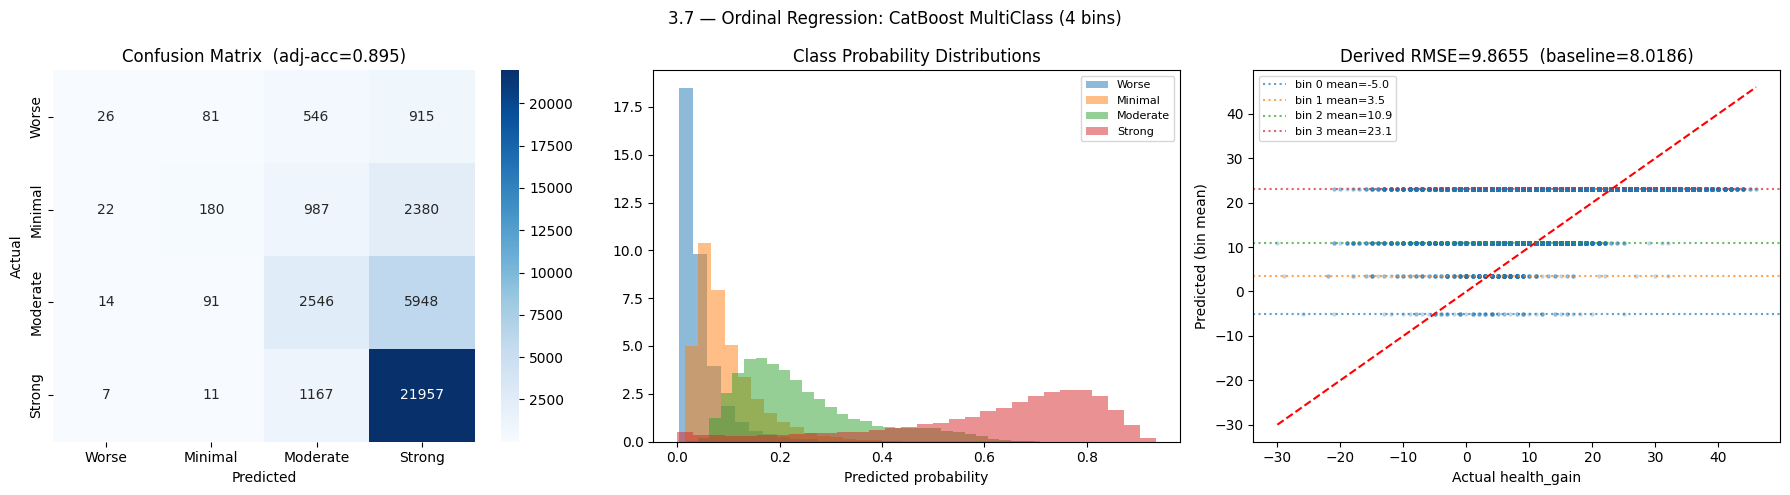


Note: derived RMSE (9.8655) is expected to be worse than regression
baseline (8.0186) because bin means lose within-bin precision.
The value of ordinal regression is interpretability + clinical binning, not raw RMSE.


In [10]:
# ── Diagnostic plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('3.7 — Ordinal Regression: CatBoost MultiClass (4 bins)', fontsize=12)

# (1) Confusion matrix
cm = confusion_matrix(y_ord_te, y_pred_ord, labels=[0, 1, 2, 3])
short_labels = ['Worse', 'Minimal', 'Moderate', 'Strong']
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=short_labels, yticklabels=short_labels, cmap='Blues')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix  (adj-acc={adjacent_acc:.3f})')

# (2) Predicted class probability distributions
for b in range(N_CLASSES):
    axes[1].hist(y_pred_proba[:, b], bins=30, alpha=0.5, label=short_labels[b], density=True)
axes[1].set_xlabel('Predicted probability')
axes[1].set_title('Class Probability Distributions')
axes[1].legend(fontsize=8)

# (3) Derived health_gain: actual vs predicted (bin mean)
axes[2].scatter(y_hg_te, y_pred_hg, alpha=0.2, s=5)
lims = [min(y_hg_te.min(), y_pred_hg.min()), max(y_hg_te.max(), y_pred_hg.max())]
axes[2].plot(lims, lims, 'r--')
# Overlay bin mean lines
for b, bm in bin_means.items():
    axes[2].axhline(bm, color=f'C{b}', linestyle=':', alpha=0.7, label=f'bin {b} mean={bm:.1f}')
axes[2].set_xlabel('Actual health_gain')
axes[2].set_ylabel('Predicted (bin mean)')
axes[2].set_title(f'Derived RMSE={derived_rmse:.4f}  (baseline={BASELINE_RMSE:.4f})')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nNote: derived RMSE ({derived_rmse:.4f}) is expected to be worse than regression')
print(f'baseline ({BASELINE_RMSE:.4f}) because bin means lose within-bin precision.')
print(f'The value of ordinal regression is interpretability + clinical binning, not raw RMSE.')